# Exploratory Data Analysis (EDA)

1. Memahami struktur & kualitas data (missing values, tipe data, rentang tanggal)
2. Analisis statistik deskriptif harga & volume
3. Visualisasi tren harga historis
4. Analisis return harian & distribusinya
5. Analisis korelasi antar saham
6. Analisis volatilitas
7. Analisis volume trading
8. Perbandingan performa antar sektor

## Import Library

In [1]:
# Import Library 
import yfinance as yf
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

# Style 
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'text.color':       '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
})

ACCENT   = '#58a6ff'
POSITIVE = '#3fb950'
NEGATIVE = '#f85149'
NEUTRAL  = '#d29922'

## 1. Load Data

In [2]:
# Definisi Sektor 
SEKTOR = {
    'Technology':   ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'ORCL', 'CRM', 'NFLX'],
    'Semiconductor':['NVDA', 'AVGO', 'AMD'],
    'EV & Auto':    ['TSLA'],
    'Financial':    ['BRK-B', 'JPM', 'V', 'MA', 'BAC'],
    'Healthcare':   ['LLY', 'UNH', 'JNJ', 'MRK', 'ABBV'],
    'Consumer':     ['WMT', 'PG', 'COST', 'HD', 'KO', 'PEP'],
    'Energy':       ['CVX', 'XOM'],
}

TICKER_SEKTOR = {t: s for s, tl in SEKTOR.items() for t in tl}
WARNA_SEKTOR  = {
    'Technology':    '#58a6ff',
    'Semiconductor': '#bc8cff',
    'EV & Auto':     '#ff7b72',
    'Financial':     '#3fb950',
    'Healthcare':    '#d29922',
    'Consumer':      '#79c0ff',
    'Energy':        '#f0883e',
}

# Load Tickers dari JSON 
with open('../Data/Raw/tickers_us.json', 'r') as f:
    raw_json = json.load(f)

TICKERS = [item['yf_symbol'] for item in raw_json['tickers'] if item['available']]
print(f'Total ticker: {len(TICKERS)}')
print(f'   {TICKERS}')

Total ticker: 30
   ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'AVGO', 'AMD', 'ORCL', 'BRK-B', 'JPM', 'V', 'MA', 'BAC', 'LLY', 'UNH', 'JNJ', 'MRK', 'ABBV', 'WMT', 'PG', 'COST', 'HD', 'KO', 'PEP', 'CVX', 'XOM', 'CRM', 'NFLX']


In [3]:
# Download Data Harian (10 tahun) 
raw = yf.download(
    TICKERS,
    period='10y',
    interval='1d',
    auto_adjust=True,
    progress=True
)

# Ambil kolom Close, Open, High, Low, Volume
close  = raw['Close'].copy()
volume = raw['Volume'].copy()
high   = raw['High'].copy()
low    = raw['Low'].copy()
open_  = raw['Open'].copy()

# Normalize timezone
close.index  = close.index.tz_localize(None)
volume.index = volume.index.tz_localize(None)
high.index   = high.index.tz_localize(None)
low.index    = low.index.tz_localize(None)
open_.index  = open_.index.tz_localize(None)

# Strip column name='Ticker' from yfinance multi-download
close.columns.name  = None
volume.columns.name = None
high.columns.name   = None
low.columns.name    = None
open_.columns.name  = None

print(f'   Rentang tanggal : {close.index[0].date()} s/d {close.index[-1].date()}')
print(f'   Jumlah baris    : {len(close):,}')
print(f'   Jumlah kolom    : {close.shape[1]}')

[*********************100%***********************]  30 of 30 completed

   Rentang tanggal : 2016-04-25 s/d 2026-04-24
   Jumlah baris    : 2,515
   Jumlah kolom    : 30


## 2. Kualitas Data Missing Values & Struktur

In [4]:
# Tabel Missing Values 
missing = close.isnull().sum()
missing_pct = (missing / len(close) * 100).round(2)

df_missing = pd.DataFrame({
    'Ticker': missing.index.tolist(),
    'Missing Rows': missing.values,
    'Missing (%)': missing_pct.values,
    'Sektor': [TICKER_SEKTOR.get(t, 'Unknown') for t in missing.index]
}).sort_values('Missing (%)', ascending=False).reset_index(drop=True)

print('Ringkasan Missing Values (Close Price)')
print(df_missing.to_string(index=False))

Ringkasan Missing Values (Close Price)
Ticker  Missing Rows  Missing (%)        Sektor
  AAPL             0          0.0    Technology
  ABBV             0          0.0    Healthcare
   AMD             0          0.0 Semiconductor
  AMZN             0          0.0    Technology
  AVGO             0          0.0 Semiconductor
   BAC             0          0.0     Financial
 BRK-B             0          0.0     Financial
  COST             0          0.0      Consumer
   CRM             0          0.0    Technology
   CVX             0          0.0        Energy
 GOOGL             0          0.0    Technology
    HD             0          0.0      Consumer
   JNJ             0          0.0    Healthcare
   JPM             0          0.0     Financial
    KO             0          0.0      Consumer
   LLY             0          0.0    Healthcare
    MA             0          0.0     Financial
  META             0          0.0    Technology
   MRK             0          0.0    Healthcare
 

## 3. Statistik Deskriptif

In [6]:
# Statistik Deskriptif Harga Close 
desc = close.describe().T
desc['Sektor'] = [TICKER_SEKTOR.get(t, 'Unknown') for t in desc.index]
desc = desc[['Sektor', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
desc.columns = ['Sektor', 'Count', 'Mean', 'Std', 'Min', 'Q1', 'Median', 'Q3', 'Max']
desc = desc.round(2)

print('Statistik Deskriptif Harga Close (USD)')
print(desc.to_string())

Statistik Deskriptif Harga Close (USD)
              Sektor   Count    Mean     Std     Min      Q1  Median      Q3      Max
AAPL      Technology  2515.0  121.53   75.69   20.58   44.37  127.57  177.27   285.92
ABBV      Healthcare  2515.0  106.74   53.53   37.61   63.62   90.31  142.06   238.71
AMD    Semiconductor  2515.0   80.35   62.04    3.45   20.32   79.96  116.78   347.81
AMZN      Technology  2515.0  126.58   58.18   30.10   84.52  122.34  170.60   263.99
AVGO   Semiconductor  2515.0   79.66   93.33   10.72   20.66   42.02   86.65   422.76
BAC        Financial  2515.0   29.93   10.16    9.80   23.11   27.41   36.96    56.93
BRK-B      Financial  2515.0  287.60  112.57  138.50  198.48  267.53  356.97   539.80
COST        Consumer  2515.0  443.95  283.00  119.40  198.26  355.10  551.40  1070.99
CRM       Technology  2515.0  184.94   68.72   67.42  137.76  182.83  242.29   364.16
CVX           Energy  2515.0  107.70   34.54   41.57   79.62   90.45  141.58   211.15
GOOGL     Techn

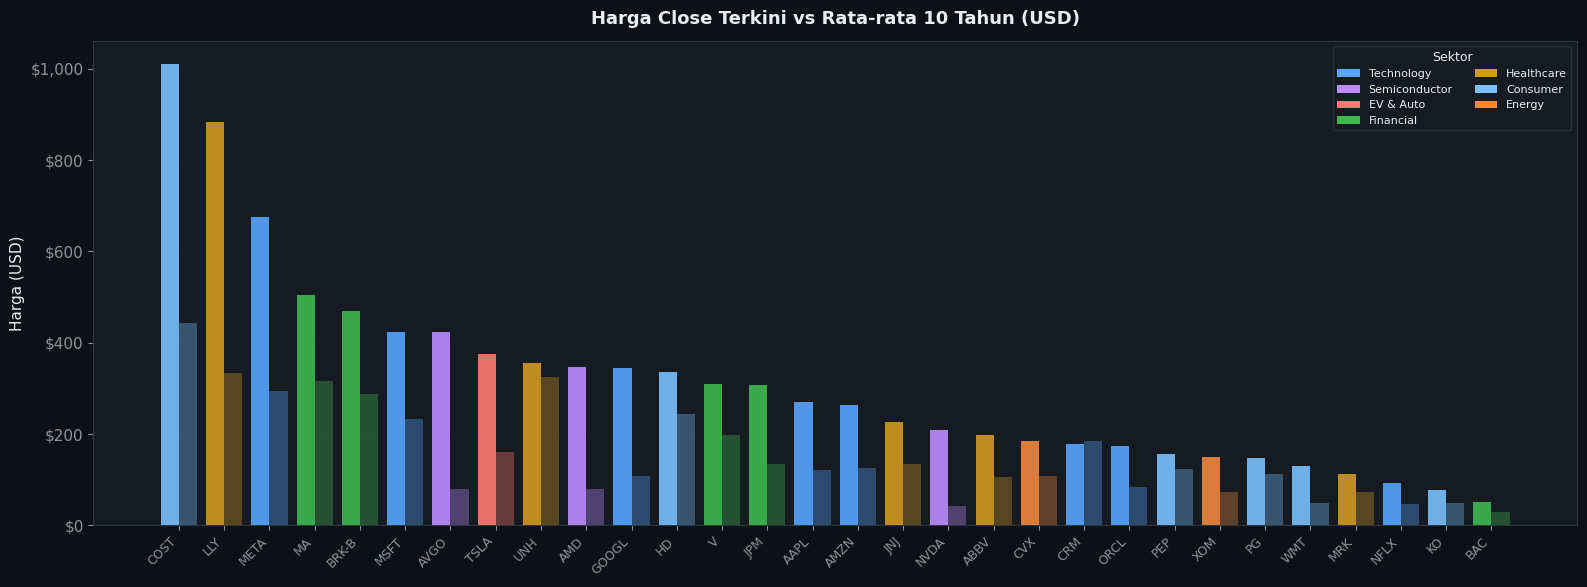

In [7]:
# Visualisasi: Harga Close Terkini vs Rata-rata 10 Tahun 
harga_terkini = close.iloc[-1].sort_values(ascending=False)
harga_rata    = close.mean().reindex(harga_terkini.index)
sektor_colors = [WARNA_SEKTOR.get(TICKER_SEKTOR.get(t, ''), ACCENT) for t in harga_terkini.index]

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

x = np.arange(len(harga_terkini))
w = 0.4
ax.bar(x - w/2, harga_terkini.values, w, label='Harga Terkini', color=sektor_colors, alpha=0.9, zorder=3)
ax.bar(x + w/2, harga_rata.values,    w, label='Rata-rata 10Y',  color=sektor_colors, alpha=0.35, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(harga_terkini.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Harga Close Terkini vs Rata-rata 10 Tahun (USD)', pad=12)
ax.set_ylabel('Harga (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.grid(axis='y', zorder=0)
ax.legend()

# Legend Sektor
from matplotlib.patches import Patch
legend_sektor = [Patch(facecolor=v, label=k) for k, v in WARNA_SEKTOR.items()]
ax.legend(handles=legend_sektor, loc='upper right', fontsize=8,
          title='Sektor', title_fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig('../Data/Processed/eda_harga_terkini_vs_rata.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

## 4. Tren Harga Historis

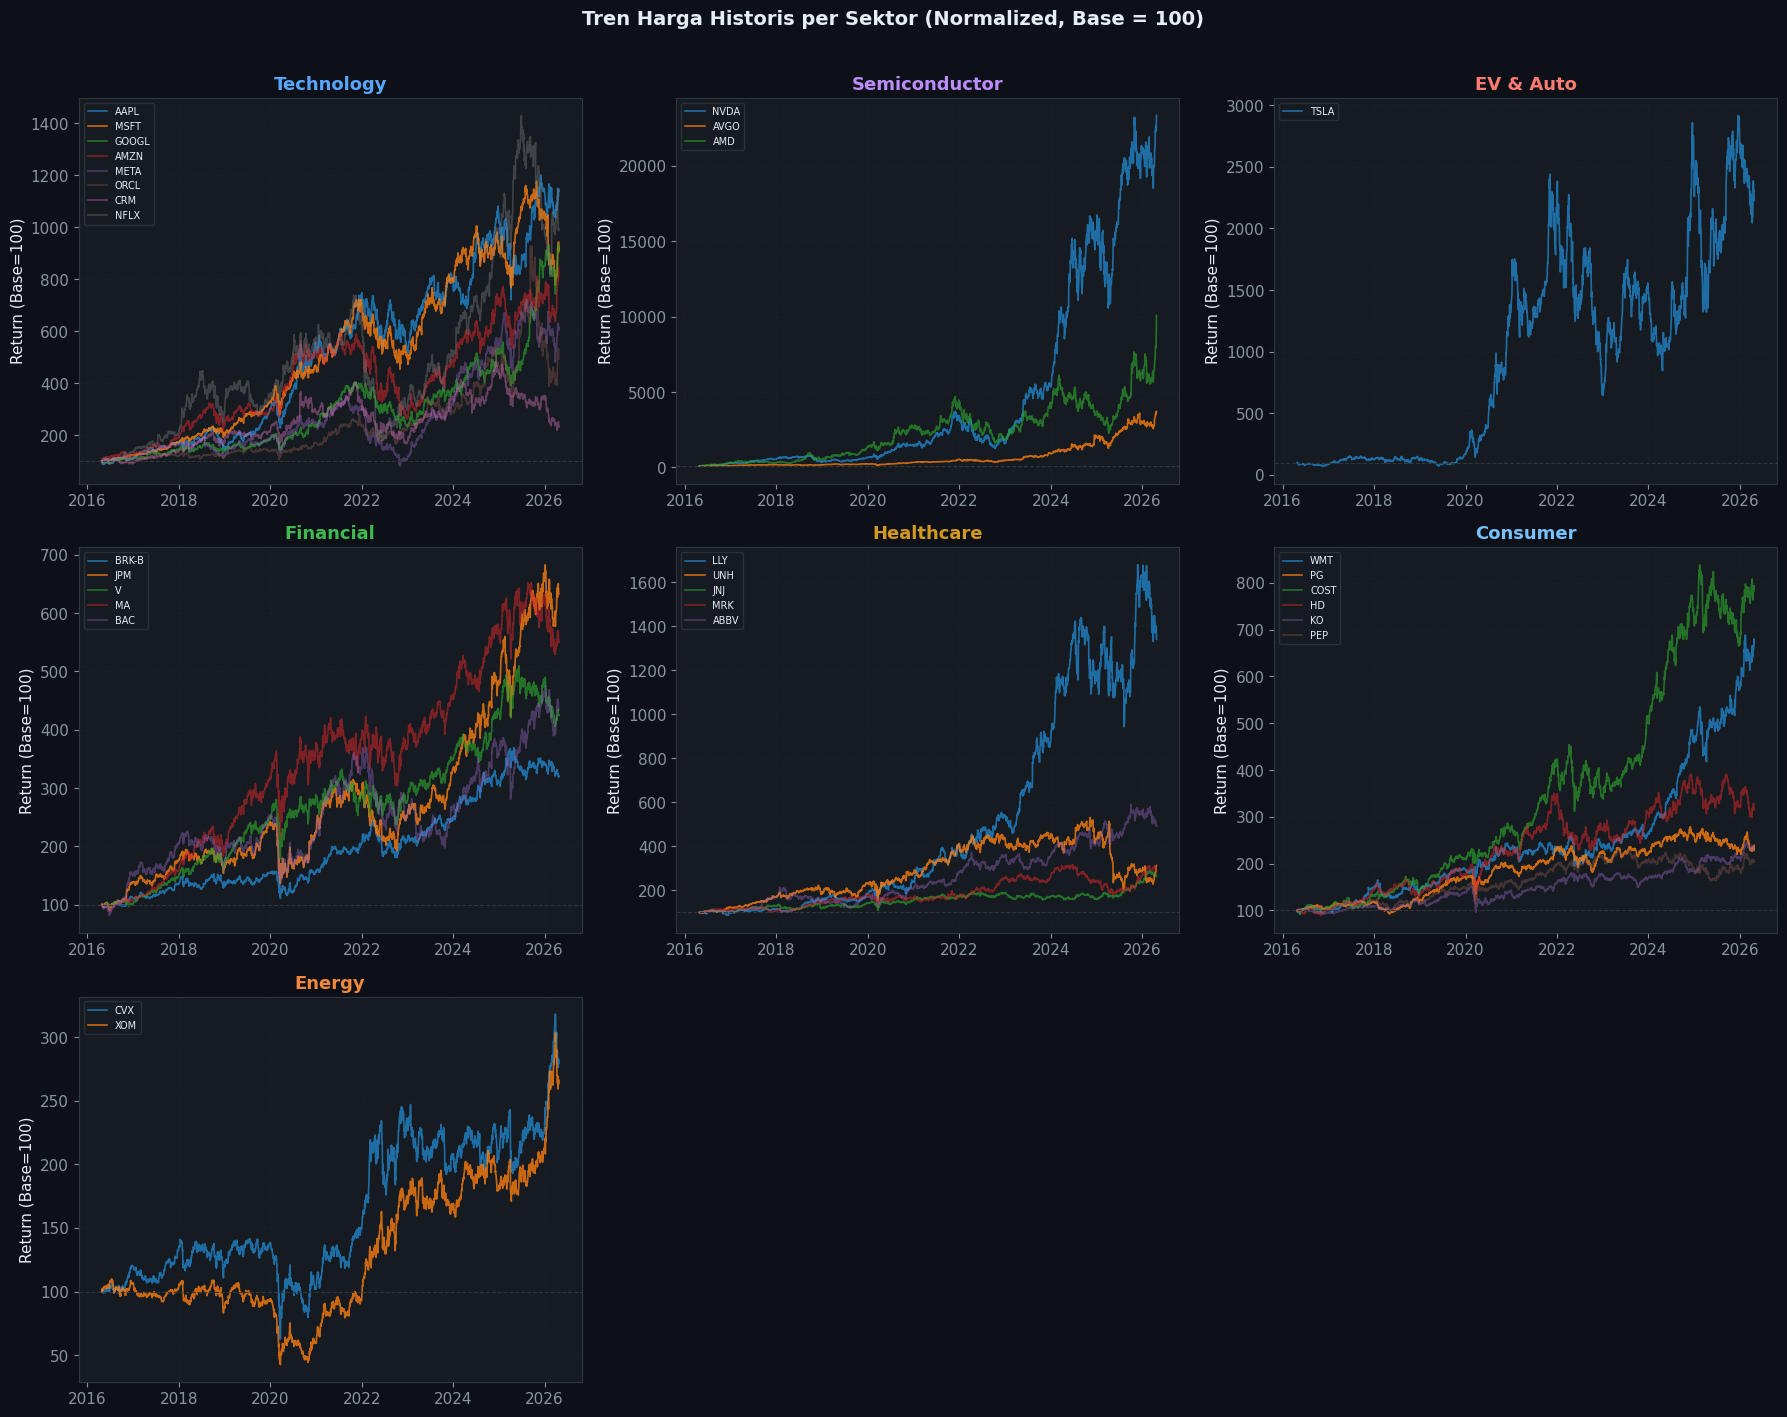

In [8]:
# Normalized Close Price (Base=100) per Sektor 
close_clean = close.dropna()
normalized  = close_clean.div(close_clean.iloc[0]) * 100

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Tren Harga Historis per Sektor (Normalized, Base = 100)',
             fontsize=14, fontweight='bold', color='#e6edf3', y=1.01)

sektors = list(SEKTOR.keys())

for idx, ax in enumerate(axes.flat):
    ax.set_facecolor('#161b22')
    if idx < len(sektors):
        s = sektors[idx]
        tickers_s = [t for t in SEKTOR[s] if t in normalized.columns]
        warna = WARNA_SEKTOR[s]
        for i, t in enumerate(tickers_s):
            alpha = 0.9 if i == 0 else max(0.4, 0.9 - i * 0.12)
            ax.plot(normalized.index, normalized[t], linewidth=1.2,
                    label=t, alpha=alpha)
        ax.axhline(100, color='#30363d', linewidth=0.8, linestyle='--')
        ax.set_title(s, color=warna)
        ax.set_ylabel('Return (Base=100)')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, loc='upper left')
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.savefig('../Data/Processed/eda_tren_historis_sektor.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

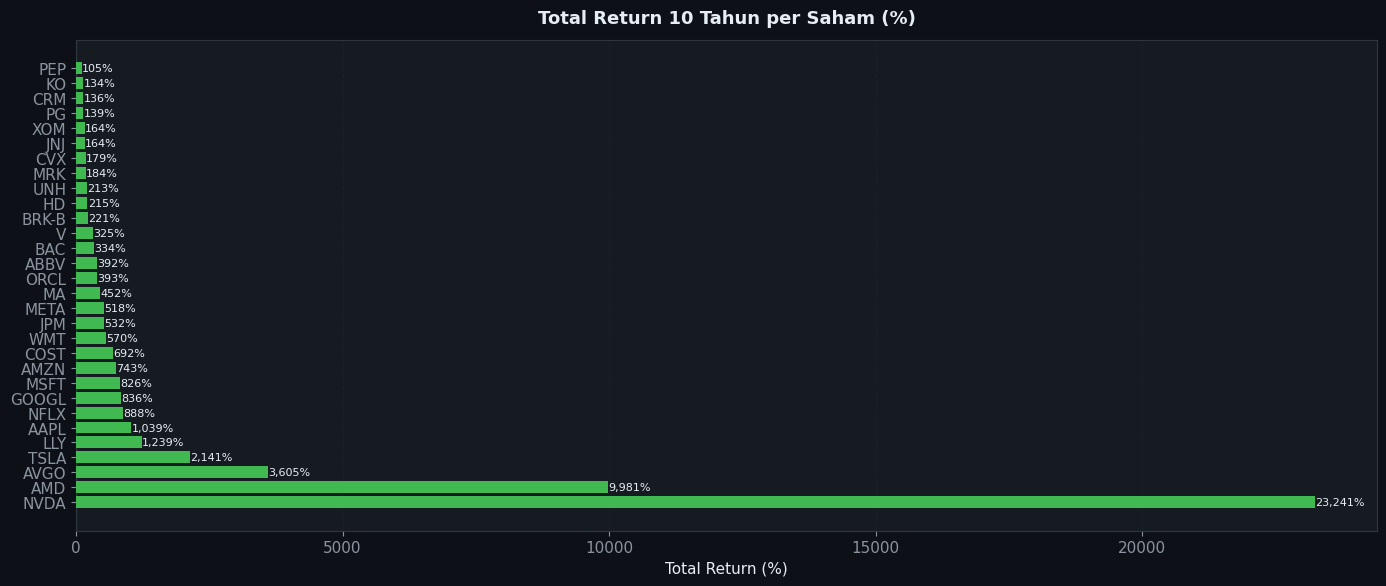


Saham terbaik  : NVDA  (23,240.8%)
Saham terburuk : PEP (104.8%)


In [9]:
# Highlight Saham Terbaik vs Terburuk (10 tahun) 
total_return = (close_clean.iloc[-1] / close_clean.iloc[0] - 1) * 100
total_return = total_return.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

colors_ret = [POSITIVE if v >= 0 else NEGATIVE for v in total_return]
bars = ax.barh(total_return.index, total_return.values, color=colors_ret, edgecolor='none', zorder=3)

ax.set_title('Total Return 10 Tahun per Saham (%)', pad=12)
ax.set_xlabel('Total Return (%)')
ax.axvline(0, color='#8b949e', linewidth=0.8)
ax.grid(axis='x', zorder=0)

for bar, val in zip(bars, total_return.values):
    offset = 5 if val >= 0 else -5
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}%', va='center', ha=ha, fontsize=8, color='#e6edf3')

plt.tight_layout()
plt.savefig('../Data/Processed/eda_total_return_10y.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

print(f'\nSaham terbaik  : {total_return.index[0]}  ({total_return.iloc[0]:,.1f}%)')
print(f'Saham terburuk : {total_return.index[-1]} ({total_return.iloc[-1]:,.1f}%)')

## 5. Analisis Return Harian & Distribusi

In [10]:
# Hitung Daily Return 
daily_return = close.pct_change().dropna()

print('Statistik Daily Return')
stats_ret = daily_return.describe().T
stats_ret['skewness'] = daily_return.skew()
stats_ret['kurtosis'] = daily_return.kurt()
stats_ret = stats_ret[['mean', 'std', 'min', 'max', 'skewness', 'kurtosis']].round(4)
stats_ret.columns = ['Mean Return', 'Std Dev', 'Min', 'Max', 'Skewness', 'Kurtosis']
stats_ret['Sektor'] = [TICKER_SEKTOR.get(t, '?') for t in stats_ret.index]
print(stats_ret.to_string())

Statistik Daily Return
       Mean Return  Std Dev     Min     Max  Skewness  Kurtosis         Sektor
AAPL        0.0011   0.0182 -0.1286  0.1533    0.1596    6.9861     Technology
ABBV        0.0008   0.0162 -0.1625  0.1377   -0.8260   12.9021     Healthcare
AMD         0.0025   0.0355 -0.2423  0.2382    0.3558    4.6430  Semiconductor
AMZN        0.0011   0.0205 -0.1405  0.1354    0.2073    5.2301     Technology
AVGO        0.0017   0.0246 -0.1991  0.2443    0.3056   11.3241  Semiconductor
BAC         0.0008   0.0194 -0.1540  0.1780    0.2205   10.8704      Financial
BRK-B       0.0005   0.0122 -0.0959  0.1161   -0.0797   11.5768      Financial
COST        0.0009   0.0138 -0.1245  0.0996   -0.3010    8.2880       Consumer
CRM         0.0006   0.0220 -0.1974  0.2604    0.2373   13.7190     Technology
CVX         0.0006   0.0183 -0.2212  0.2274   -0.3321   25.5906         Energy
GOOGL       0.0011   0.0182 -0.1163  0.1022    0.0002    4.4462     Technology
HD          0.0006   0.0156 -

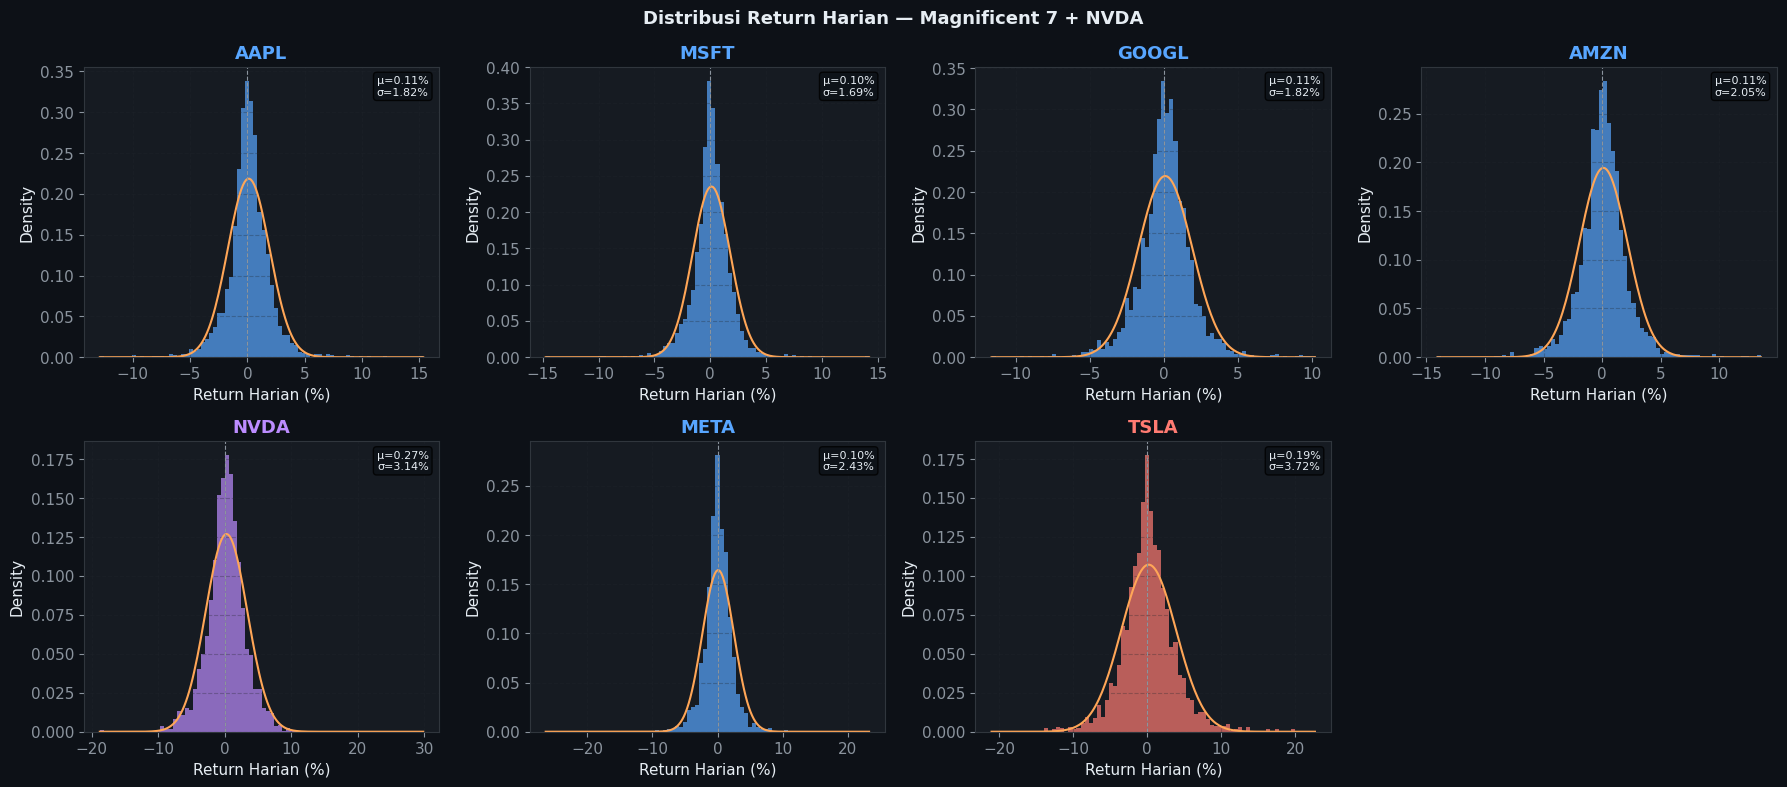

In [11]:
# Distribusi Return Harian: Magnificent 7 
mag7 = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Distribusi Return Harian — Magnificent 7 + NVDA',
             fontsize=13, fontweight='bold', color='#e6edf3')

for idx, ticker in enumerate(mag7):
    ax = axes.flat[idx]
    ax.set_facecolor('#161b22')
    if ticker in daily_return.columns:
        data = daily_return[ticker].dropna() * 100
        warna = WARNA_SEKTOR.get(TICKER_SEKTOR.get(ticker, ''), ACCENT)
        ax.hist(data, bins=80, color=warna, alpha=0.7, edgecolor='none', density=True)

        # Fit normal
        from scipy import stats as scipy_stats
        mu, sigma = data.mean(), data.std()
        x_range = np.linspace(data.min(), data.max(), 200)
        ax.plot(x_range, scipy_stats.norm.pdf(x_range, mu, sigma),
                color='#ffa657', linewidth=1.5, label='Normal Fit')

        ax.axvline(0, color='#8b949e', linewidth=0.8, linestyle='--')
        ax.set_title(ticker, color=warna)
        ax.set_xlabel('Return Harian (%)')
        ax.set_ylabel('Density')
        ax.grid(True, alpha=0.3)
        ax.text(0.97, 0.97, f'μ={mu:.2f}%\nσ={sigma:.2f}%',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=8, color='#e6edf3',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#0d1117', alpha=0.8))

axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.savefig('../Data/Processed/eda_distribusi_return_mag7.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

## 6. Analisis Volatilitas

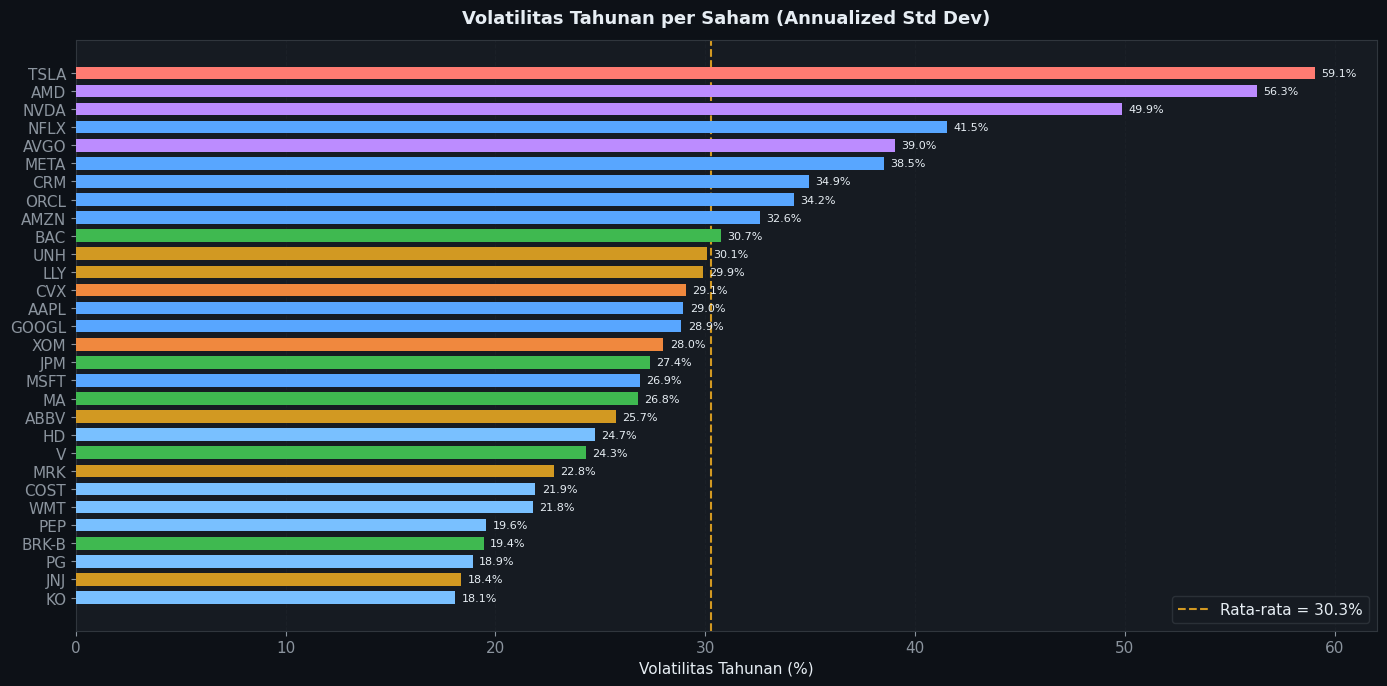

In [12]:
# Volatilitas Tahunan (Annualized Std Dev) 
vol_annual = daily_return.std() * np.sqrt(252) * 100  # dalam %
vol_annual = vol_annual.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

colors_vol = [WARNA_SEKTOR.get(TICKER_SEKTOR.get(t, ''), ACCENT) for t in vol_annual.index]
bars = ax.barh(vol_annual.index, vol_annual.values, color=colors_vol, edgecolor='none',
               zorder=3, height=0.7)

avg_vol = vol_annual.mean()
ax.axvline(avg_vol, color=NEUTRAL, linewidth=1.5, linestyle='--',
           label=f'Rata-rata = {avg_vol:.1f}%')

ax.set_title('Volatilitas Tahunan per Saham (Annualized Std Dev)', pad=12)
ax.set_xlabel('Volatilitas Tahunan (%)')
ax.grid(axis='x', zorder=0)
ax.legend()

for bar, val in zip(bars, vol_annual.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left', fontsize=8, color='#e6edf3')

plt.tight_layout()
plt.savefig('../Data/Processed/eda_volatilitas_tahunan.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

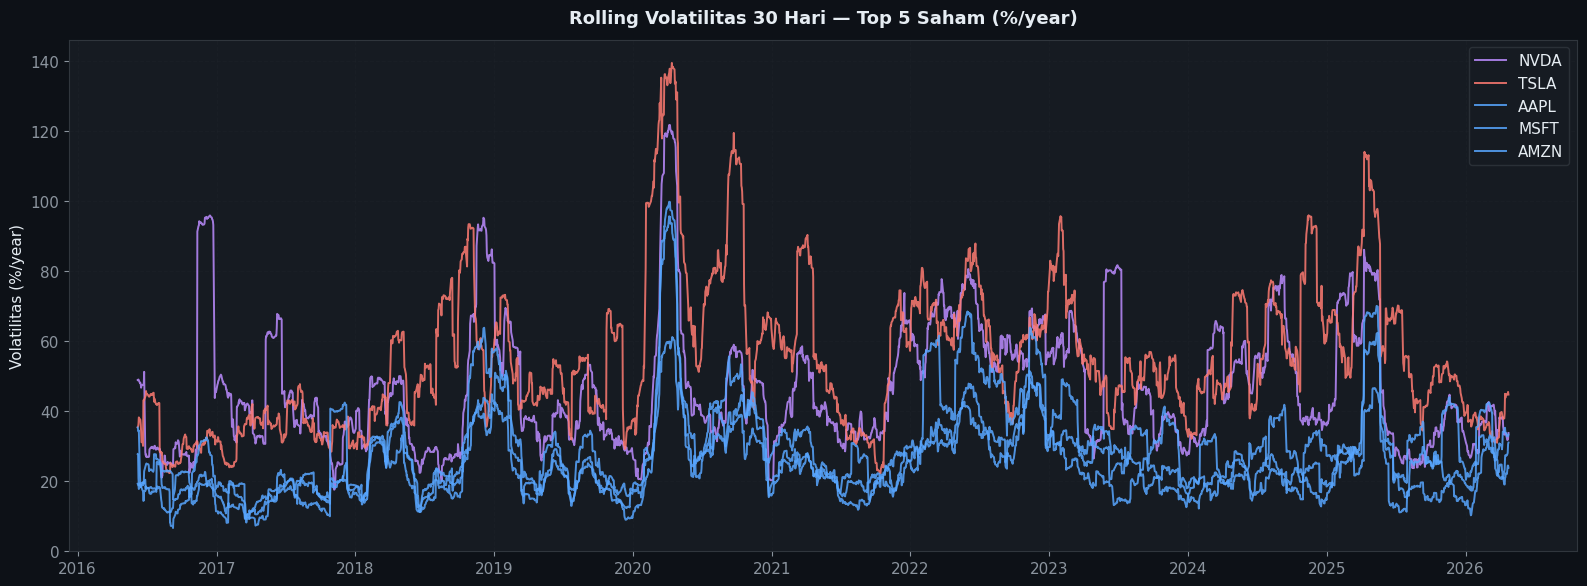

In [13]:
# Rolling Volatilitas 30 Hari: Top 5 Saham 
top5 = ['NVDA', 'TSLA', 'AAPL', 'MSFT', 'AMZN']
roll_vol = daily_return[top5].rolling(30).std() * np.sqrt(252) * 100

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

palette = [WARNA_SEKTOR.get(TICKER_SEKTOR.get(t, ''), ACCENT) for t in top5]
for t, c in zip(top5, palette):
    ax.plot(roll_vol.index, roll_vol[t], linewidth=1.4, label=t, color=c, alpha=0.85)

ax.set_title('Rolling Volatilitas 30 Hari — Top 5 Saham (%/year)', pad=12)
ax.set_ylabel('Volatilitas (%/year)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('../Data/Processed/eda_rolling_volatilitas.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

## 7. Analisis Korelasi

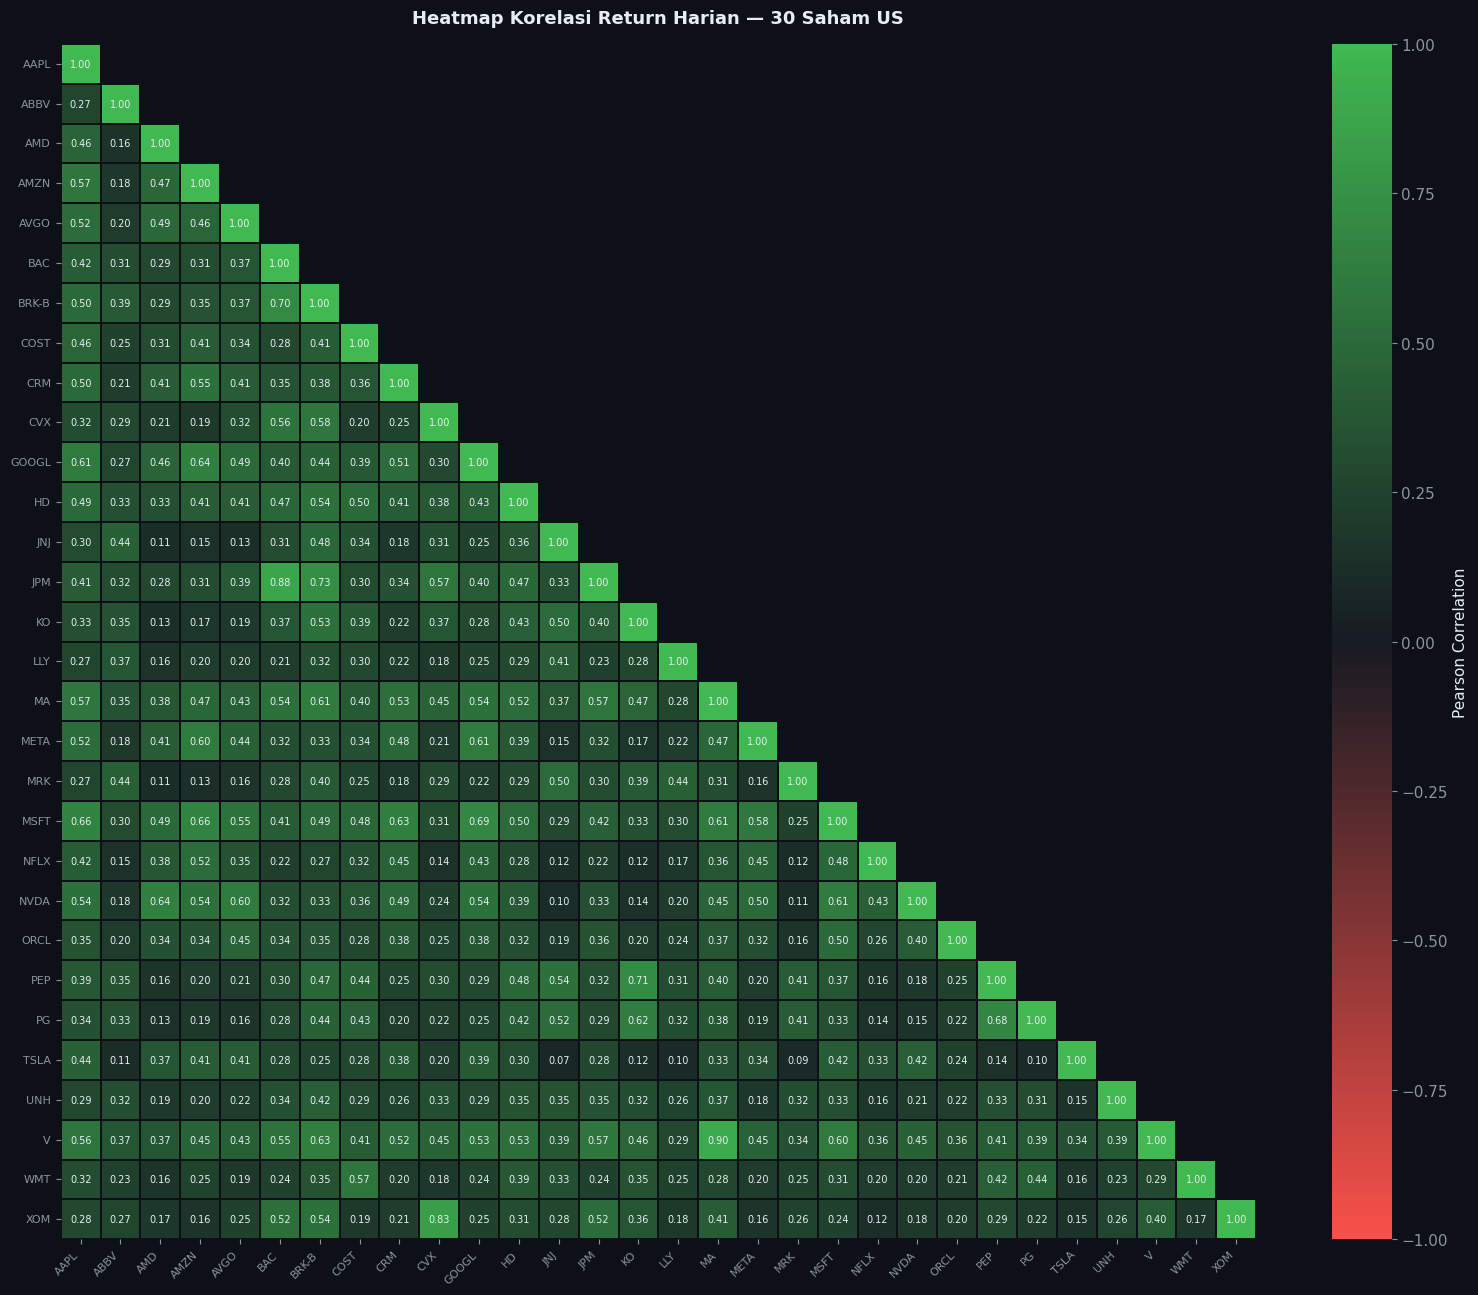

In [14]:
# Heatmap Korelasi Return Harian 
corr_matrix = daily_return.corr()

# Custom colormap (merah - putih - hijau)
cmap_custom = LinearSegmentedColormap.from_list(
    'stockit', ['#f85149', '#161b22', '#3fb950'], N=256
)

fig, ax = plt.subplots(figsize=(16, 13))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    ax=ax,
    mask=mask,
    cmap=cmap_custom,
    vmin=-1, vmax=1,
    annot=True, fmt='.2f',
    annot_kws={'size': 7, 'color': '#e6edf3'},
    linewidths=0.3,
    linecolor='#0d1117',
    square=True,
    cbar_kws={'label': 'Pearson Correlation'}
)

ax.set_title('Heatmap Korelasi Return Harian — 30 Saham US', pad=15, fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('../Data/Processed/eda_korelasi_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

In [15]:
# Top 10 Pasangan Korelasi Tertinggi & Terendah 
corr_copy = corr_matrix.copy()
corr_copy.index.name = 'Ticker_A'
corr_copy.columns.name = 'Ticker_B'
corr_pairs = corr_copy.where(np.tril(np.ones(corr_copy.shape), k=-1).astype(bool))
corr_stack  = corr_pairs.stack().reset_index()
corr_stack.columns = ['Ticker A', 'Ticker B', 'Korelasi']
corr_stack = corr_stack.sort_values('Korelasi', ascending=False)

print('TOP 10 Pasangan Korelasi TERTINGGI:')
print(corr_stack.head(10).to_string(index=False))
print('\nTOP 10 Pasangan Korelasi TERENDAH:')
print(corr_stack.tail(10).to_string(index=False))

TOP 10 Pasangan Korelasi TERTINGGI:
Ticker A Ticker B  Korelasi
       V       MA  0.900685
     JPM      BAC  0.881840
     XOM      CVX  0.834879
     JPM    BRK-B  0.733205
     PEP       KO  0.714576
   BRK-B      BAC  0.704414
    MSFT    GOOGL  0.685566
      PG      PEP  0.677164
    MSFT     AMZN  0.661951
    MSFT     AAPL  0.660025

TOP 10 Pasangan Korelasi TERENDAH:
Ticker A Ticker B  Korelasi
    NFLX      MRK  0.117128
    TSLA     ABBV  0.114333
     JNJ      AMD  0.114101
    NVDA      MRK  0.110524
     MRK      AMD  0.110246
    NVDA      JNJ  0.104517
    TSLA      LLY  0.098127
    TSLA       PG  0.096665
    TSLA      MRK  0.094005
    TSLA      JNJ  0.071592


## 8. Analisis Volume Trading

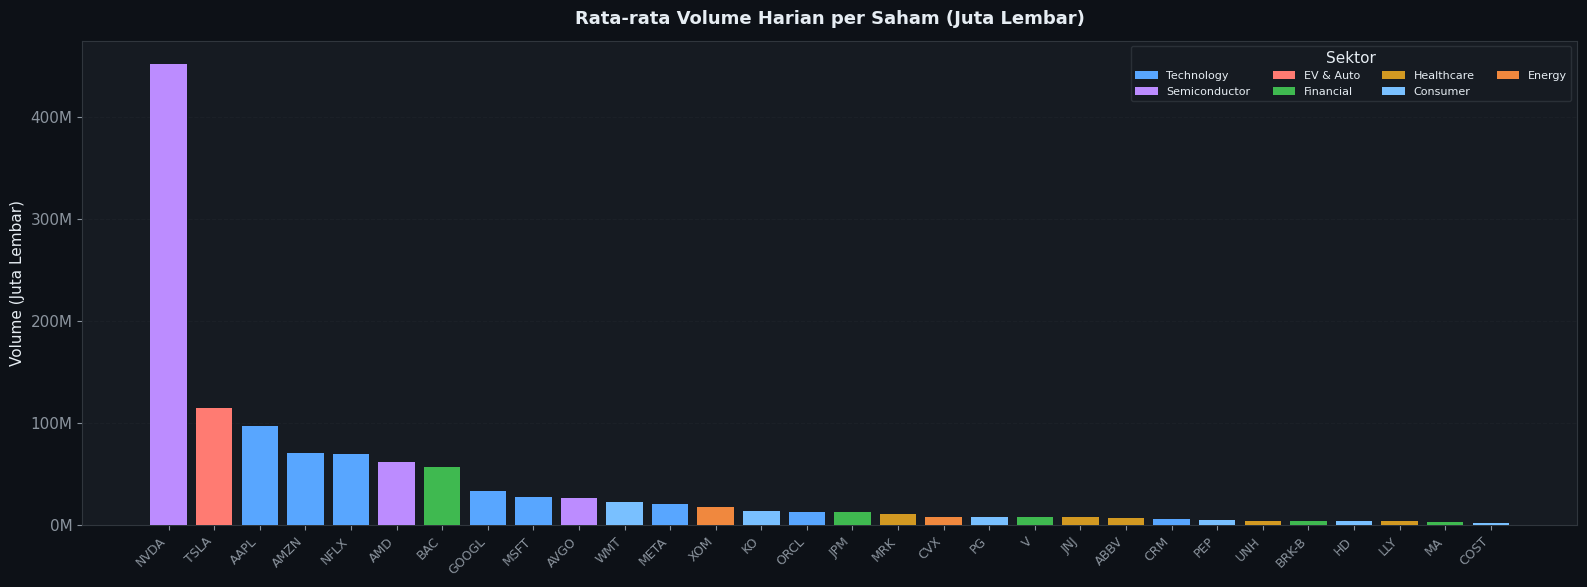

In [16]:
# Rata-rata Volume Harian per Saham 
avg_volume = volume.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

colors_v = [WARNA_SEKTOR.get(TICKER_SEKTOR.get(t, ''), ACCENT) for t in avg_volume.index]
bars = ax.bar(avg_volume.index, avg_volume.values / 1e6, color=colors_v,
              edgecolor='none', zorder=3)

ax.set_title('Rata-rata Volume Harian per Saham (Juta Lembar)', pad=12)
ax.set_ylabel('Volume (Juta Lembar)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}M'))
ax.grid(axis='y', zorder=0)
plt.xticks(rotation=45, ha='right', fontsize=9)

legend_sektor = [Patch(facecolor=v, label=k) for k, v in WARNA_SEKTOR.items()]
ax.legend(handles=legend_sektor, fontsize=8, ncol=4, loc='upper right', title='Sektor')

plt.tight_layout()
plt.savefig('../Data/Processed/eda_volume_harian.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

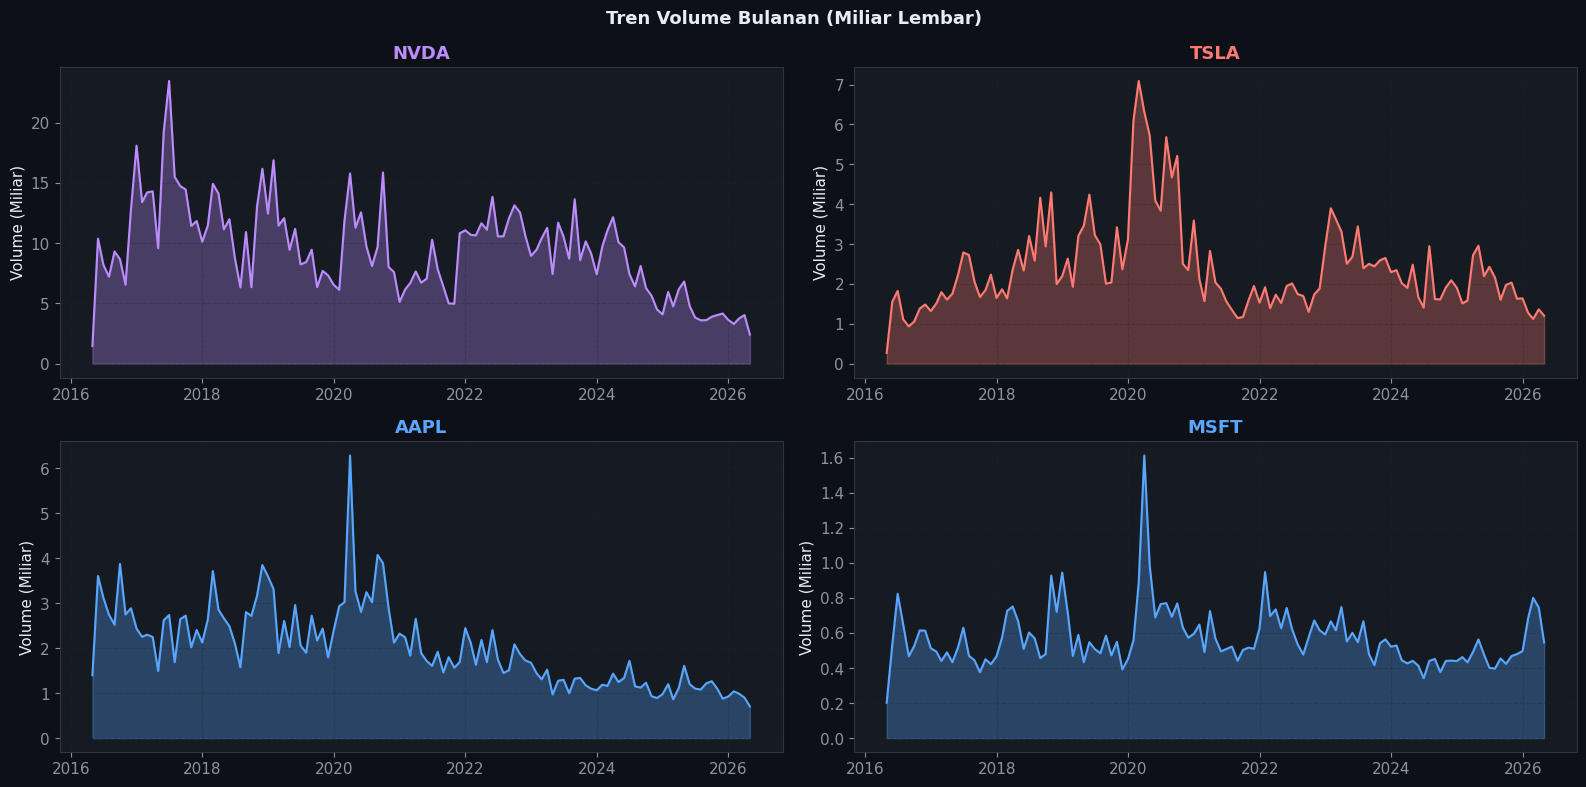

In [17]:
# Tren Volume Bulanan: NVDA & TSLA (paling volatile) 
highlight = ['NVDA', 'TSLA', 'AAPL', 'MSFT']

vol_monthly = volume[highlight].resample('ME').sum() / 1e9  # miliar

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Tren Volume Bulanan (Miliar Lembar)', fontsize=13,
             fontweight='bold', color='#e6edf3')

for ax, ticker in zip(axes.flat, highlight):
    ax.set_facecolor('#161b22')
    warna = WARNA_SEKTOR.get(TICKER_SEKTOR.get(ticker, ''), ACCENT)
    ax.fill_between(vol_monthly.index, vol_monthly[ticker],
                    alpha=0.3, color=warna)
    ax.plot(vol_monthly.index, vol_monthly[ticker],
            linewidth=1.5, color=warna, label=ticker)
    ax.set_title(ticker, color=warna)
    ax.set_ylabel('Volume (Miliar)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../Data/Processed/eda_volume_bulanan.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

## 9. Risk vs Return Scatter Plot

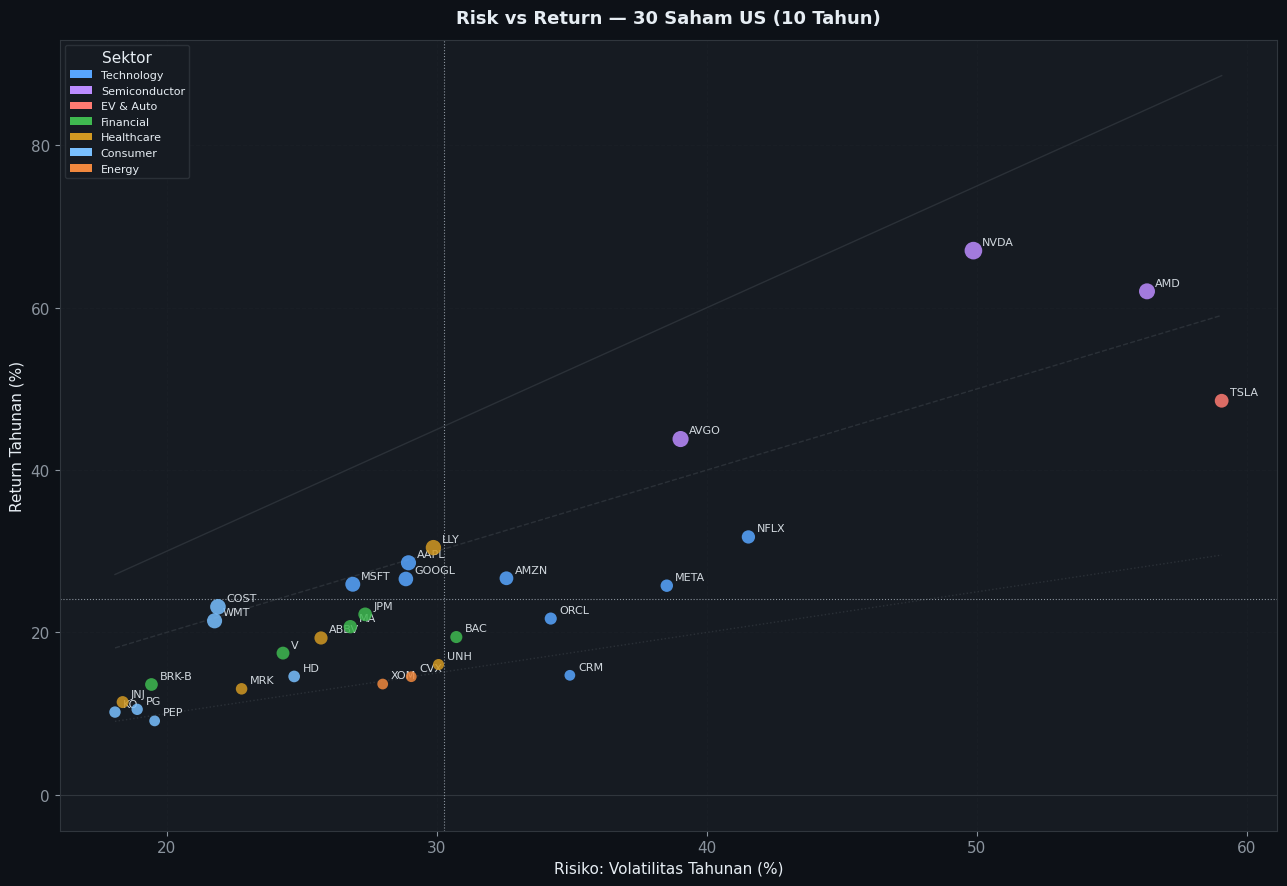

Ranking Sharpe Ratio
Ticker  Ann Return (%)  Volatility (%)  Sharpe Ratio        Sektor
  NVDA           67.04           49.88         1.344 Semiconductor
  AVGO           43.83           39.03         1.123 Semiconductor
   AMD           62.03           56.31         1.102 Semiconductor
  COST           23.16           21.91         1.057      Consumer
   LLY           30.45           29.88         1.019    Healthcare
  AAPL           28.58           28.96         0.987    Technology
   WMT           21.43           21.78         0.984      Consumer
  MSFT           25.94           26.90         0.964    Technology
 GOOGL           26.59           28.86         0.921    Technology
  TSLA           48.55           59.07         0.822     EV & Auto
  AMZN           26.68           32.59         0.819    Technology
   JPM           22.23           27.36         0.813     Financial
    MA           20.71           26.81         0.773     Financial
  NFLX           31.77           41.55   

In [18]:
# Risk-Return Chart 
ann_return = daily_return.mean() * 252 * 100  # %
ann_vol    = daily_return.std() * np.sqrt(252) * 100  # %
sharpe     = ann_return / ann_vol  # simplified (risk-free = 0)

fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

for ticker in ann_return.index:
    x = ann_vol[ticker]
    y = ann_return[ticker]
    sektor = TICKER_SEKTOR.get(ticker, '')
    c = WARNA_SEKTOR.get(sektor, ACCENT)
    sh = sharpe[ticker]
    size = max(60, sh * 120) if sh > 0 else 60

    ax.scatter(x, y, color=c, s=size, alpha=0.85, edgecolors='none', zorder=4)
    ax.annotate(ticker, (x, y), textcoords='offset points', xytext=(6, 4),
                fontsize=8, color='#e6edf3', alpha=0.9)

# Garis sharpe ratio
x_line = np.linspace(ann_vol.min(), ann_vol.max(), 100)
for sr, ls in [(0.5, ':'), (1.0, '--'), (1.5, '-')]:
    ax.plot(x_line, sr * x_line, linestyle=ls, color='#30363d', linewidth=1,
            label=f'Sharpe = {sr}', alpha=0.8)

ax.axhline(0, color='#30363d', linewidth=0.8)
ax.axvline(ann_vol.mean(), color='#8b949e', linewidth=0.8, linestyle=':', label='Avg Volatility')
ax.axhline(ann_return.mean(), color='#8b949e', linewidth=0.8, linestyle=':', label='Avg Return')

ax.set_title('Risk vs Return — 30 Saham US (10 Tahun)', pad=12)
ax.set_xlabel('Risiko: Volatilitas Tahunan (%)')
ax.set_ylabel('Return Tahunan (%)')
ax.grid(True, alpha=0.3)

legend_sektor = [Patch(facecolor=v, label=k) for k, v in WARNA_SEKTOR.items()]
ax.legend(handles=legend_sektor, loc='upper left', fontsize=8, title='Sektor')

plt.tight_layout()
plt.savefig('../Data/Processed/eda_risk_return.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

# Tabel Sharpe
df_sharpe = pd.DataFrame({
    'Ticker': sharpe.index.tolist(),
    'Ann Return (%)': ann_return.round(2).values,
    'Volatility (%)': ann_vol.round(2).values,
    'Sharpe Ratio':   sharpe.round(3).values,
    'Sektor': [TICKER_SEKTOR.get(t, '?') for t in sharpe.index]
}).sort_values('Sharpe Ratio', ascending=False).reset_index(drop=True)

print('Ranking Sharpe Ratio')
print(df_sharpe.to_string(index=False))

## 10. Perbandingan Performa Antar Sektor

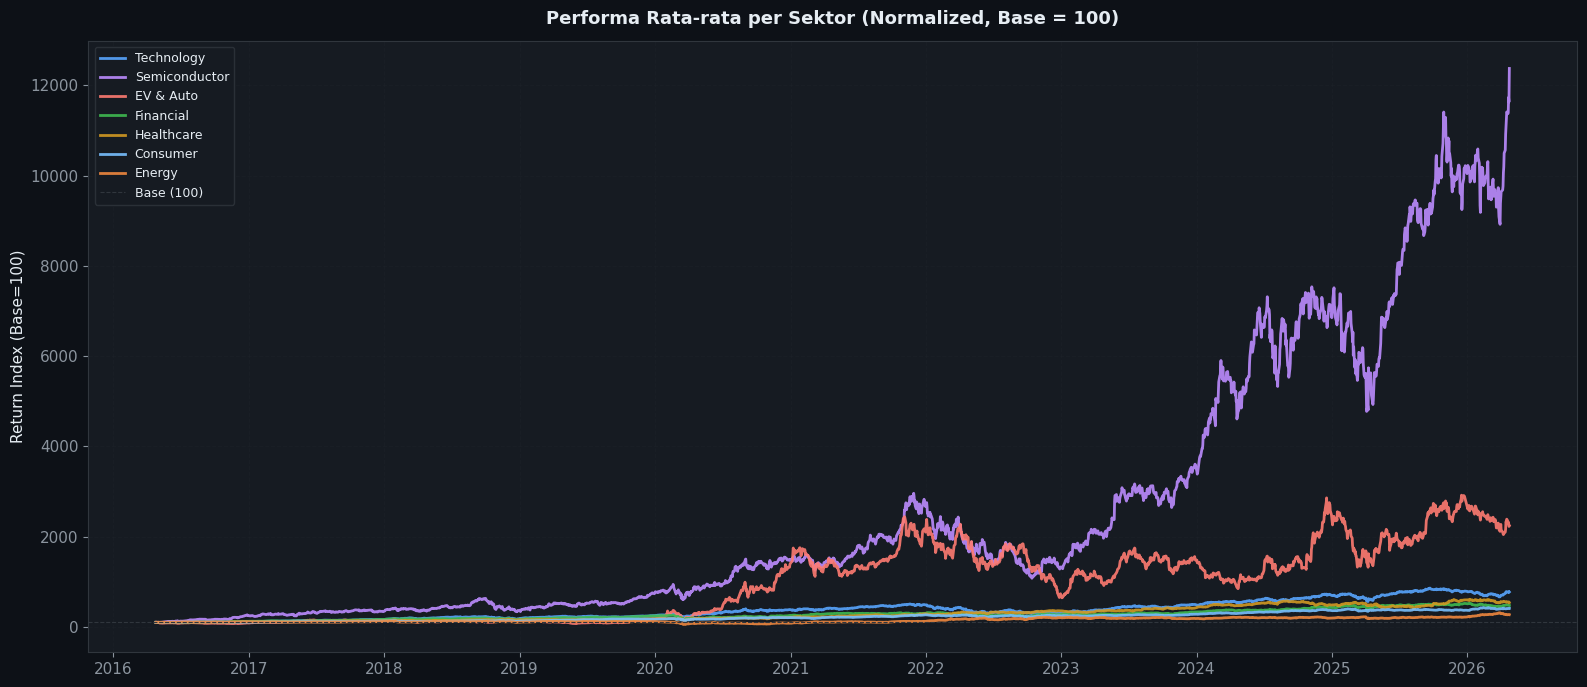

In [19]:
# Return per Sektor (rata-rata) 
sektor_return = {}
for sektor, tickers_s in SEKTOR.items():
    valid = [t for t in tickers_s if t in normalized.columns]
    if valid:
        sektor_return[sektor] = normalized[valid].mean(axis=1)

df_sektor = pd.DataFrame(sektor_return)

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

for sektor, warna in WARNA_SEKTOR.items():
    if sektor in df_sektor.columns:
        ax.plot(df_sektor.index, df_sektor[sektor], linewidth=2,
                label=sektor, color=warna, alpha=0.9)

ax.axhline(100, color='#30363d', linewidth=0.8, linestyle='--', label='Base (100)')
ax.set_title('Performa Rata-rata per Sektor (Normalized, Base = 100)', pad=12)
ax.set_ylabel('Return Index (Base=100)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('../Data/Processed/eda_performa_sektor.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

In [20]:
# Ringkasan Return & Volatilitas per Sektor 
rows = []
for sektor, tickers_s in SEKTOR.items():
    valid = [t for t in tickers_s if t in ann_return.index]
    if valid:
        rows.append({
            'Sektor': sektor,
            'Jumlah Saham': len(valid),
            'Avg Return/Y (%)': round(ann_return[valid].mean(), 2),
            'Avg Volatility (%)': round(ann_vol[valid].mean(), 2),
            'Avg Sharpe': round(sharpe[valid].mean(), 3),
            'Best Ticker': ann_return[valid].idxmax(),
            'Worst Ticker': ann_return[valid].idxmin(),
        })

df_sektor_summary = pd.DataFrame(rows).sort_values('Avg Return/Y (%)', ascending=False)

print('Ringkasan Performa per Sektor')
print(df_sektor_summary.to_string(index=False))

Ringkasan Performa per Sektor
       Sektor  Jumlah Saham  Avg Return/Y (%)  Avg Volatility (%)  Avg Sharpe Best Ticker Worst Ticker
Semiconductor             3             57.63               48.41       1.190        NVDA         AVGO
    EV & Auto             1             48.55               59.07       0.822        TSLA         TSLA
   Technology             8             25.22               33.32       0.772        NFLX          CRM
    Financial             5             18.68               25.73       0.727         JPM        BRK-B
   Healthcare             5             18.06               25.37       0.700         LLY          JNJ
     Consumer             6             14.83               20.83       0.703        COST          PEP
       Energy             2             14.09               28.53       0.494         CVX          XOM


## 11. Candlestick-Style OHLCV Preview (AAPL & NVDA)

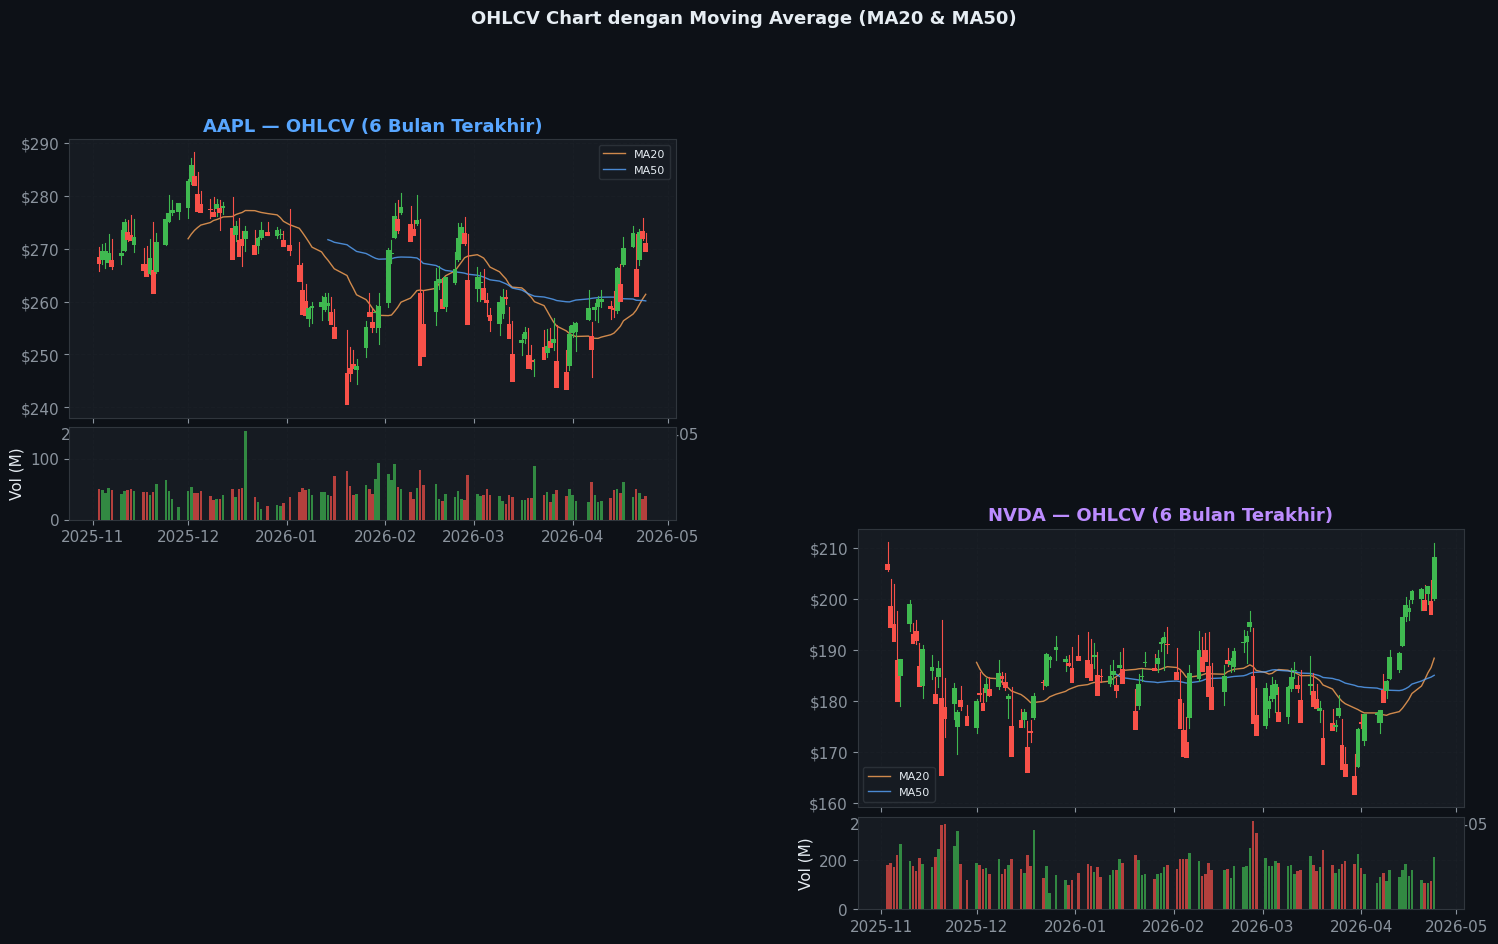

In [21]:
# OHLCV Chart 6 Bulan Terakhir 
def plot_ohlcv(ticker, ax_price, ax_vol, color):
    df_t = pd.DataFrame({
        'Open':  open_[ticker],
        'High':  high[ticker],
        'Low':   low[ticker],
        'Close': close[ticker],
        'Volume': volume[ticker],
    }).dropna().last('6ME')

    for _, row in df_t.iterrows():
        c   = POSITIVE if row['Close'] >= row['Open'] else NEGATIVE
        ax_price.plot([row.name, row.name], [row['Low'], row['High']],
                      color=c, linewidth=0.8, zorder=3)
        ax_price.bar(row.name, row['Close'] - row['Open'],
                     bottom=min(row['Open'], row['Close']),
                     color=c, width=1.5, zorder=4)

    # Moving average
    ma20 = df_t['Close'].rolling(20).mean()
    ma50 = df_t['Close'].rolling(50).mean()
    ax_price.plot(df_t.index, ma20, color='#ffa657', linewidth=1, label='MA20', alpha=0.8)
    ax_price.plot(df_t.index, ma50, color=ACCENT,   linewidth=1, label='MA50', alpha=0.8)
    ax_price.set_title(f'{ticker} — OHLCV (6 Bulan Terakhir)', color=color)
    ax_price.legend(fontsize=8)
    ax_price.grid(True, alpha=0.3)
    ax_price.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))

    # Volume bars
    colors_v = [POSITIVE if c >= o else NEGATIVE
                for c, o in zip(df_t['Close'], df_t['Open'])]
    ax_vol.bar(df_t.index, df_t['Volume'] / 1e6, color=colors_v, alpha=0.7, zorder=3)
    ax_vol.set_ylabel('Vol (M)')
    ax_vol.grid(True, alpha=0.3)

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#0d1117')
gs = GridSpec(4, 2, height_ratios=[3, 1, 3, 1], figure=fig, hspace=0.05, wspace=0.3)

for col, (ticker, color) in enumerate(zip(['AAPL', 'NVDA'], [WARNA_SEKTOR['Technology'], WARNA_SEKTOR['Semiconductor']])):
    ax_p = fig.add_subplot(gs[0 if col == 0 else 2, col])
    ax_v = fig.add_subplot(gs[1 if col == 0 else 3, col], sharex=ax_p)
    ax_p.set_facecolor('#161b22')
    ax_v.set_facecolor('#161b22')
    plot_ohlcv(ticker, ax_p, ax_v, color)

plt.suptitle('OHLCV Chart dengan Moving Average (MA20 & MA50)', fontsize=13,
             fontweight='bold', color='#e6edf3', y=1.01)
plt.savefig('../Data/Processed/eda_ohlcv_chart.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

## 12. Ringkasan & Temuan EDA

In [ ]:
# Ringkasan Akhir 
print(f'  Periode Data   : {close_clean.index[0].date()} s/d {close_clean.index[-1].date()}')
print(f'  Jumlah Saham   : {len(TICKERS)}')
print(f'  Jumlah Sektor  : {len(SEKTOR)}')
print(f'  Missing Values : {close.isnull().sum().sum()} total')
print()
print('  [Return 10 Tahun]')
print(f'Top Performer  : {total_return.index[0]} ({total_return.iloc[0]:,.1f}%)')
print(f'Low Performer  : {total_return.index[-1]} ({total_return.iloc[-1]:,.1f}%)')
print()
print('  [Volatilitas]')
print(f'Paling Volatil : {vol_annual.idxmax()} ({vol_annual.max():.1f}%/year)')
print(f'Paling Stabil  : {vol_annual.idxmin()} ({vol_annual.min():.1f}%/year)')
print()
print('  [Sharpe Ratio]')
print(f'Sharpe Terbaik : {df_sharpe.iloc[0]["Ticker"]} ({df_sharpe.iloc[0]["Sharpe Ratio"]:.3f})')
print()
print('  [Korelasi]')
top_corr = corr_stack.iloc[0]
low_corr = corr_stack.iloc[-1]
print(f'Korelasi Tertinggi: {top_corr["Ticker A"]} ↔ {top_corr["Ticker B"]} ({top_corr["Korelasi"]:.3f})')
print(f'Korelasi Terendah : {low_corr["Ticker A"]} ↔ {low_corr["Ticker B"]} ({low_corr["Korelasi"]:.3f})')

       STOCKIT — RINGKASAN EDA
  Periode Data   : 2016-04-25 s/d 2026-04-24
  Jumlah Saham   : 30
  Jumlah Sektor  : 7
  Missing Values : 0 total

  [Return 10 Tahun]
Top Performer  : NVDA (23,240.8%)
Low Performer  : PEP (104.8%)

  [Volatilitas]
Paling Volatil : TSLA (59.1%/year)
Paling Stabil  : KO (18.1%/year)

  [Sharpe Ratio]
Sharpe Terbaik : NVDA (1.344)

  [Korelasi]
Korelasi Tertinggi: V ↔ MA (0.901)
Korelasi Terendah : TSLA ↔ JNJ (0.072)
